## Fig 2 surface + network plots: Viewing 1 -> Viewing 2 shift by condition

Reads the LMER outputs from `002._subject_by_node_Viewing1_Viewing2.Rmd` and renders
(1) the 17-network effect distribution and (2) the parcel-wise effect on the cortical
surface. Per-iteration resampling outputs are kept outside this repo to keep it small;
`002` regenerates them.

In [1]:
import os
import sys
from glob import glob

import numpy as np
import pandas as pd
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from statsmodels.stats.multitest import multipletests

from brainspace.datasets import load_parcellation
from neuromaps.datasets import fetch_fslr

sys.path.append('../utils/')
from plotting_brains_surfplot import map_values_to_atlas, Plot
from plotting_network_plots import plot_17N_effect_distribution_horizontal

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica Neue']
mpl.rcParams['font.size'] = 14

# Orange (control) -> white -> green (experimental)
# Edit this gradient at https://eltos.github.io/gradient/#homemade_diverging=EA8500-FFFFFF-00755F
homemade_diverging = LinearSegmentedColormap.from_list('homemade_diverging', (
    (0.000, (0.918, 0.522, 0.000)),
    (0.500, (1.000, 1.000, 1.000)),
    (1.000, (0.000, 0.459, 0.373))))

# Resampling outputs are stored outside the repo so it stays small; 002 regenerates them.
RESAMPLED_DIR = '../../../MadLibs_pub_REML/code/02._condition_reinterpretation_clean'
MODEL_OUTPUTS = 'model_outputs'
RESULTS_DIR = '../../results/condition_plots/'

/Users/f004p59/.local/lib/python3.7/site-packages/nilearn/__init__.py:67: FutureWarning: Python 3.7 support is deprecated and will be removed in release 0.12 of Nilearn. Consider switching to Python 3.9 or 3.10.
  _python_deprecation_warnings()


In [2]:
surfaces = fetch_fslr()
lh, rh = surfaces['inflated']
atlas_surf = load_parcellation('schaefer', 100, join=True)

### Network-level effect, summarized across matched-length resampling iterations

In [3]:
files = sorted(glob(os.path.join(
    RESAMPLED_DIR, 'resampled_matched_condition_17N',
    'across_network_estimate_p_neural_shift_Condition_iter_*.csv')))
print("Number of iterations:", len(files))

sig_counts = {}
r_values = {}
p_values = {}

for f in files:

    df = pd.read_csv(f)

    for _, row in df.iterrows():
        net = row["network"]
        r   = row["Conditionexpt_estimate"]
        p   = row["Conditionexpt_p_value"]

        if net not in r_values:
            r_values[net] = []
            p_values[net] = []

        r_values[net].append(r)
        p_values[net].append(p)

    # FDR within iteration
    df["q_value"] = multipletests(df["Conditionexpt_p_value"], method="fdr_bh")[1]

    for net in df.loc[df["q_value"] < 0.05, "network"]:
        sig_counts[net] = sig_counts.get(net, 0) + 1

summary_rows = []

for net in r_values.keys():

    r_array = np.array(r_values[net])
    p_array = np.array(p_values[net])

    prop_sig = sig_counts.get(net, 0) / len(files)

    summary_rows.append({
        "network": net,
        "ConditioncondCond_over_Expt_estimate": np.median(r_array),
        "mean_R": np.mean(r_array),
        "std_R": np.std(r_array),
        # report p only where the effect held in >95% of iterations
        "ConditioncondCond_over_Expt_p_value": np.median(p_array) if prop_sig > 0.95 else np.nan,
        "mean_p_value": np.mean(p_array) if prop_sig > 0.95 else np.nan,
        "prop_sig_q<.05": prop_sig
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("ConditioncondCond_over_Expt_estimate", ascending=False)
)

print(summary_df)

Number of iterations: 100
         network  ConditioncondCond_over_Expt_estimate    mean_R     std_R  \
1        VisCent                              0.122264  0.122556  0.009744   
4        SomMotB                              0.083641  0.082991  0.008233   
5        SomMotA                              0.075451  0.074841  0.008612   
6      DorsAttnB                              0.071734  0.071367  0.009495   
3      DorsAttnA                              0.060735  0.060858  0.007997   
8          ContA                              0.056736  0.056244  0.008760   
2        VisPeri                              0.054876  0.054357  0.007988   
0       DefaultC                              0.043574  0.043609  0.005732   
14       TempPar                              0.038284  0.038844  0.007334   
9   SalVentAttnA                              0.035417  0.035885  0.007265   
13      DefaultB                              0.027714  0.028087  0.006752   
16         ContB                      

../utils/plotting_network_plots.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  network_df['network'] = network_df['network'].replace({'ContA':'FPN-A','ContB':'FPN-B','ContC':'FPN-C','DefaultA':'DMN-A','DefaultB':'DMN-B','DefaultC':'DMN-C','SalVentAttnA':'VAN-A','SalVentAttnB':'VAN-B', 'DorsAttnA':'DAN-A','DorsAttnB':'DAN-B'})


['DAN-A' 'DAN-B' 'DMN-A' 'DMN-B' 'DMN-C' 'FPN-A' 'FPN-B' 'FPN-C' 'LimbicA'
 'LimbicB' 'SomMotA' 'SomMotB' 'TempPar' 'VAN-A' 'VAN-B' 'VisCent'
 'VisPeri']
renamed them!

Creating horizontal 17N distribution plot for: ConditioncondCond_over_Expt
Mode: Bar graph only
Sorting by network family grouping


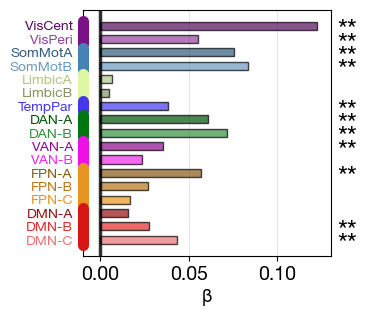


=== ConditioncondCond_over_Expt Summary (17N) ===

VisCent:
  Network Beta: 0.1223 **
  q-value: 1.0000e-03
  Node count: 7
  Node mean: 0.0696
  Node median: 0.0684
  Node std: 0.0199
  Node range: [0.0463, 0.0961]

VisPeri:
  Network Beta: 0.0549 **
  q-value: 1.0000e-03
  Node count: 6
  Node mean: 0.0286
  Node median: 0.0239
  Node std: 0.0118
  Node range: [0.0187, 0.0462]

SomMotA:
  Network Beta: 0.0755 **
  q-value: 1.0000e-03
  Node count: 6
  Node mean: 0.0112
  Node median: 0.0089
  Node std: 0.0135
  Node range: [-0.0065, 0.0321]

SomMotB:
  Network Beta: 0.0836 **
  q-value: 1.0000e-03
  Node count: 8
  Node mean: 0.0036
  Node median: 0.0017
  Node std: 0.0068
  Node range: [-0.0020, 0.0188]

LimbicA:
  Network Beta: 0.0065 
  q-value: 1.0000e+00
  Node count: 3
  Node mean: -0.0015
  Node median: -0.0003
  Node std: 0.0056
  Node range: [-0.0076, 0.0033]

LimbicB:
  Network Beta: 0.0049 
  q-value: 1.0000e+00
  Node count: 2
  Node mean: 0.0026
  Node median: 0.0026
  

In [4]:
effect_name = "ConditioncondCond_over_Expt"

network_df_plot = summary_df.rename(columns={
    "ConditioncondCond_over_Expt_estimate": "estimate",
    "ConditioncondCond_over_Expt_p_value": "p_value"})

network_df_plot["effect"] = effect_name

network_df_plot["p_fdr"] = np.where(
    network_df_plot["prop_sig_q<.05"] > 0.95,
    0.001,   # force stars
    1.0)     # no stars

all_sub = pd.read_csv(os.path.join(
    MODEL_OUTPUTS, 'across_node_estimate_p_neural_shift_Condition_condition_diffs.csv'))

plot_17N_effect_distribution_horizontal(
    network_df=network_df_plot[["network", "effect", "estimate", "p_fdr"]],
    node_df=all_sub,
    min_val_manual=-0.01,
    max_val_manual=0.13,
    x_offset=-.4,
    effect=effect_name,
    output_folder=RESULTS_DIR,
    ascending=True,
    sort_by_effect=False,
    show_bars=True)

### Parcel-level effect on the cortical surface (median across iterations)

In [5]:
files = sorted(glob(os.path.join(
    RESAMPLED_DIR, 'resampled_matched_condition',
    'across_node_estimate_p_neural_shift_Condition_iter_*.csv')))
print("Number of iterations:", len(files))

all_iters = []
for f in files:
    df = pd.read_csv(f)
    df["iteration"] = os.path.basename(f)
    all_iters.append(df)

all_nodes_df = pd.concat(all_iters, ignore_index=True)

node_summary = (
    all_nodes_df
    .groupby("node")
    .agg(
        median_estimate=("Conditionexpt_estimate", "median"),
        mean_estimate=("Conditionexpt_estimate", "mean"),
        std_estimate=("Conditionexpt_estimate", "std"),
        median_p=("Conditionexpt_p_value", "median"))
    .reset_index()
    .sort_values("node")
)

print(node_summary.head())

Number of iterations: 100
   node  median_estimate  mean_estimate  std_estimate      median_p
0     1         0.035067       0.035104      0.006311  1.069286e-02
1     2         0.172765       0.173853      0.012736  2.355488e-10
2     3         0.046721       0.046244      0.008558  1.116690e-02
3     4         0.145093       0.145130      0.011583  5.322917e-10
4     5         0.090520       0.088847      0.011555  3.283561e-05


Parcels significant at p < 0.05: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 25, 29, 33, 48, 50, 51, 52, 53, 54, 55, 56, 58, 60, 61, 62, 63, 67, 69, 71, 72, 74, 77, 83, 85, 86, 91, 92, 95, 96, 98]
Parcels significant at q < 0.05: [0, 1, 2, 3, 4, 5, 6, 7, 8, 11, 12, 13, 15, 16, 17, 19, 20, 21, 22, 29, 50, 51, 53, 54, 56, 58, 60, 61, 62, 71, 72, 77, 85, 91, 98]


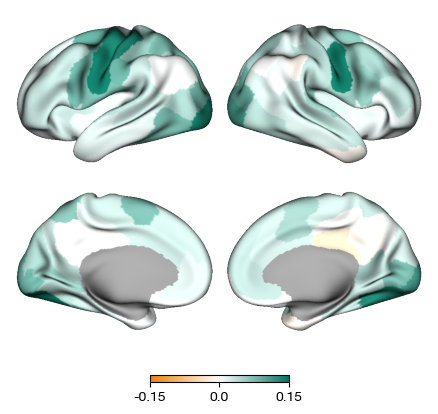

In [6]:
threshold = 0.05

vals = node_summary['median_estimate'].to_numpy()
p_vals = node_summary['median_p'].to_numpy()
q_vals = multipletests(p_vals, method='fdr_bh')[1]

print(f"Parcels significant at p < {threshold}: {np.where(p_vals < threshold)[0].tolist()}")
print(f"Parcels significant at q < {threshold}: {np.where(q_vals < threshold)[0].tolist()}")

p = Plot(lh, rh, views=['lateral', 'medial'])
p.add_layer(map_values_to_atlas(atlas_surf, vals), cbar=True, cmap=homemade_diverging,
            color_range=(-0.15, 0.15), zero_transparent=False)

fig = p.build()
fig.savefig(os.path.join(RESULTS_DIR, 'surf_condition_comparisons_matched_size_median.png'),
            dpi=300, transparent=True)